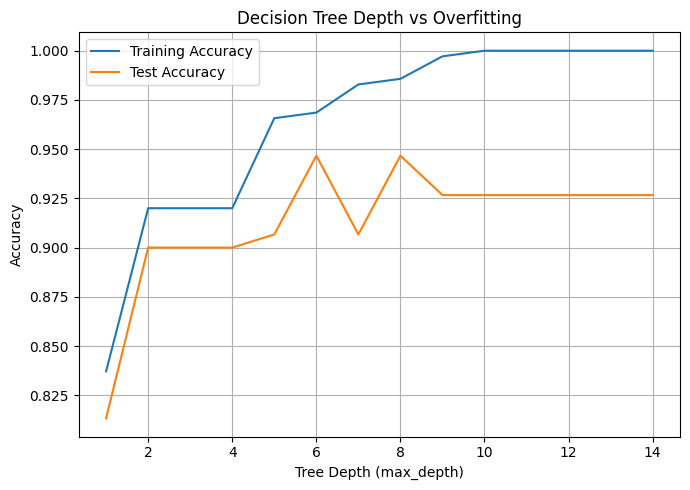

Best depth based on test accuracy: 6


In [1]:
# decision_tree_depth_demo.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1) Create a toy dataset
# ---------------------------------------------------------
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------------------------------------
# 2) Train trees with different depths
# ---------------------------------------------------------
depths = list(range(1, 15))
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))
test_acc

# ---------------------------------------------------------
# 3) Plot performance vs depth
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(depths, train_acc, label="Training Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Overfitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4) Print key observation
# ---------------------------------------------------------
best_depth = depths[np.argmax(test_acc)]
print(f"Best depth based on test accuracy: {best_depth}")